In [ ]:
!pip install -q kaggle opencv-python albumentations tqdm


In [ ]:
from google.colab import files

files.upload()

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


Saving kaggle.json to kaggle.json


In [ ]:
!kaggle competitions download -c aptos2019-blindness-detection

^C


/usr/local/lib/python3.10/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.5 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


        id_code  diagnosis
0  000c1434d8d7          2
1  001639a390f0          4
2  0024cdab0c1e          1
3  002c21358ce6          0
4  005b95c28852          0
Checking for missing values:
id_code      0
diagnosis    0
dtype: int64
Class distribution before augmentation:
diagnosis
0    1805
2     999
1     370
4     295
3     193
Name: count, dtype: int64


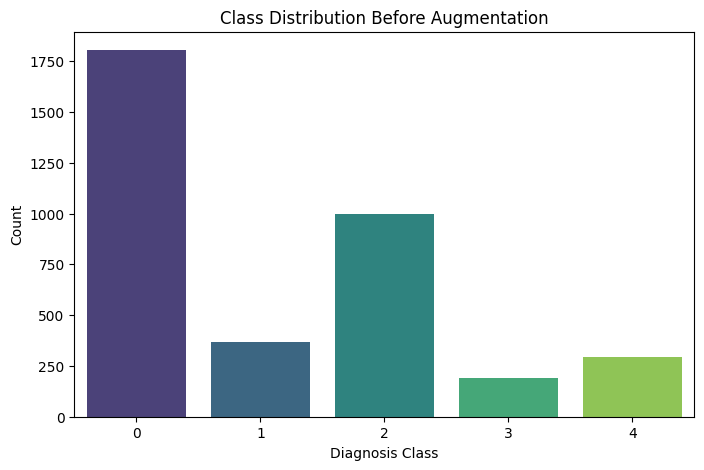

In [ ]:
import os
import pandas as pd
import cv2
import numpy as np
import uuid
import matplotlib.pyplot as plt
import albumentations as A
import seaborn as sns

DATASET_DIR = "aptos_data"
AUGMENTED_IMG_DIR = "augmented_images"
TRAIN_IMG_DIR = os.path.join(DATASET_DIR, "train_images")
UPDATED_CSV = "updated_train.csv"
os.makedirs(AUGMENTED_IMG_DIR, exist_ok=True)

df = pd.read_csv(TRAIN_CSV)
print(df.head())

print("Checking for missing values:")
print(df.isnull().sum())

print("Class distribution before augmentation:")
print(df['diagnosis'].value_counts())

plt.figure(figsize=(8,5))
sns.countplot(x=df['diagnosis'], palette="viridis")
plt.title("Class Distribution Before Augmentation")
plt.xlabel("Diagnosis Class")
plt.ylabel("Count")
plt.show()

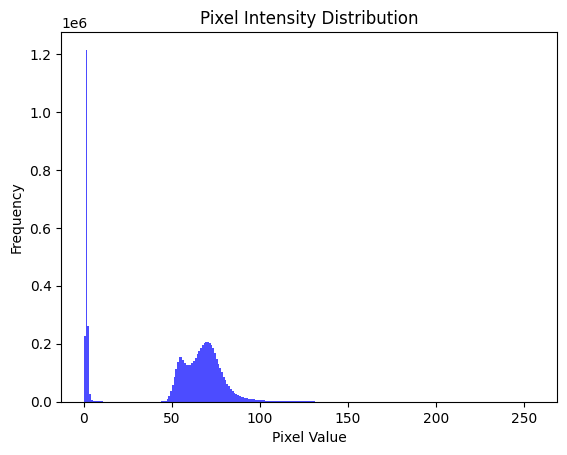

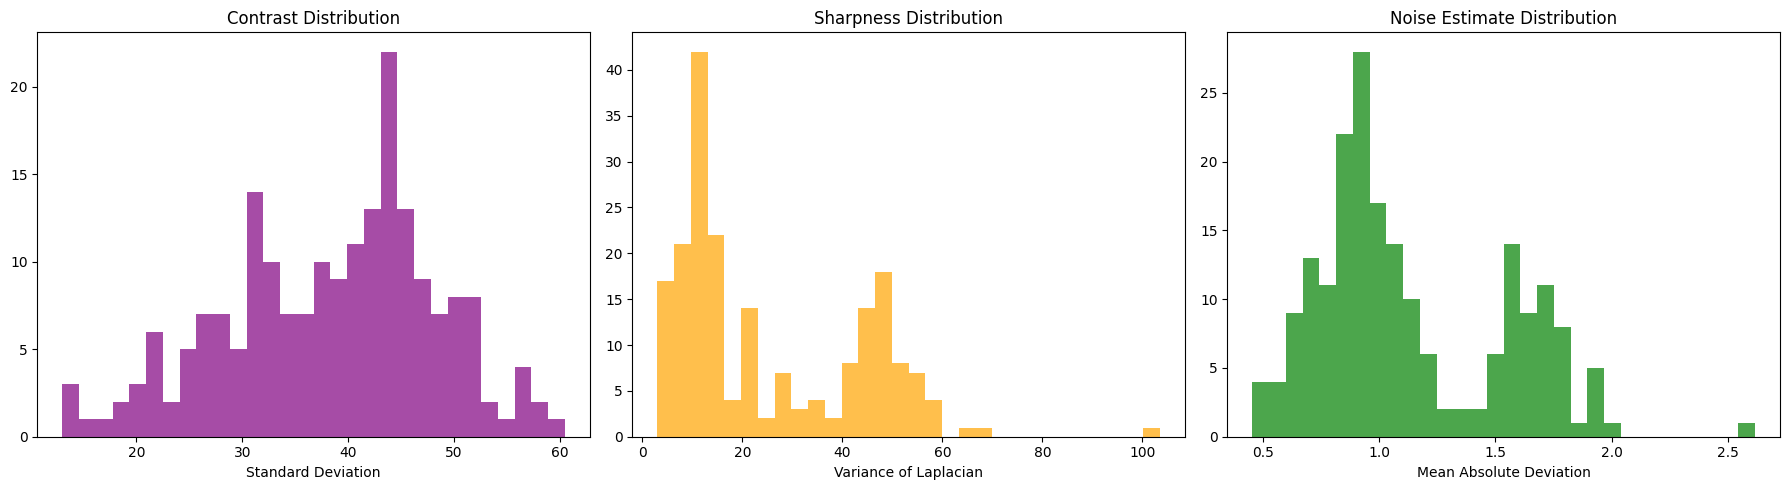

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

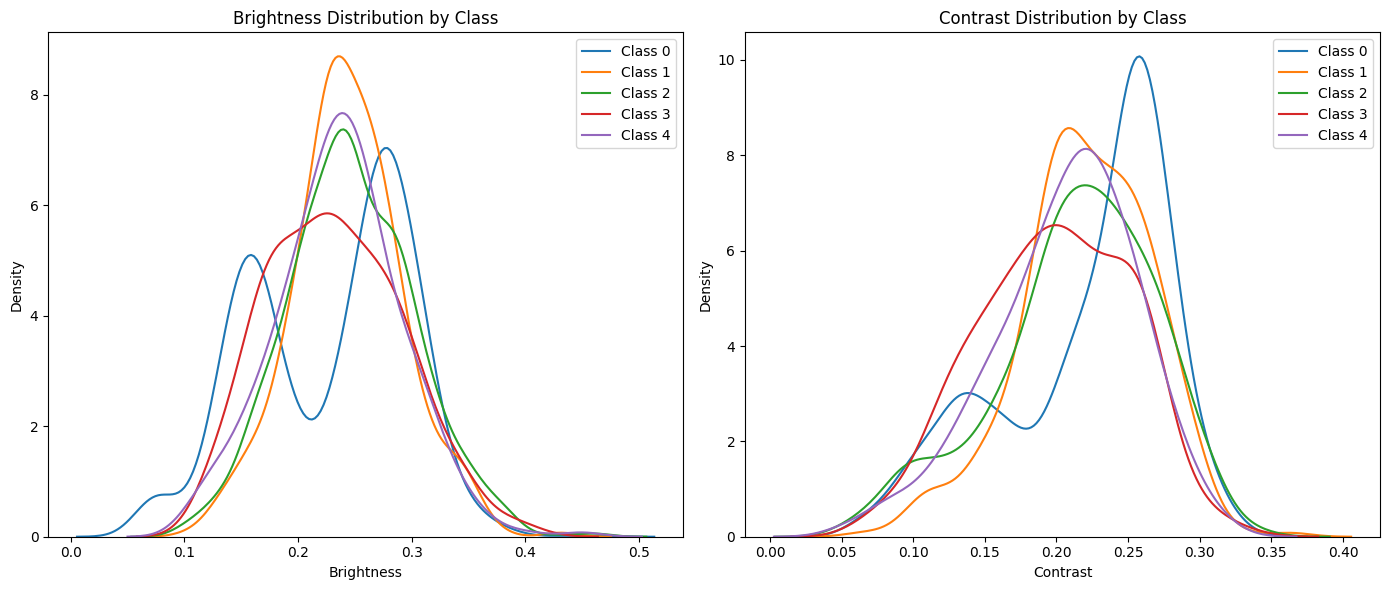

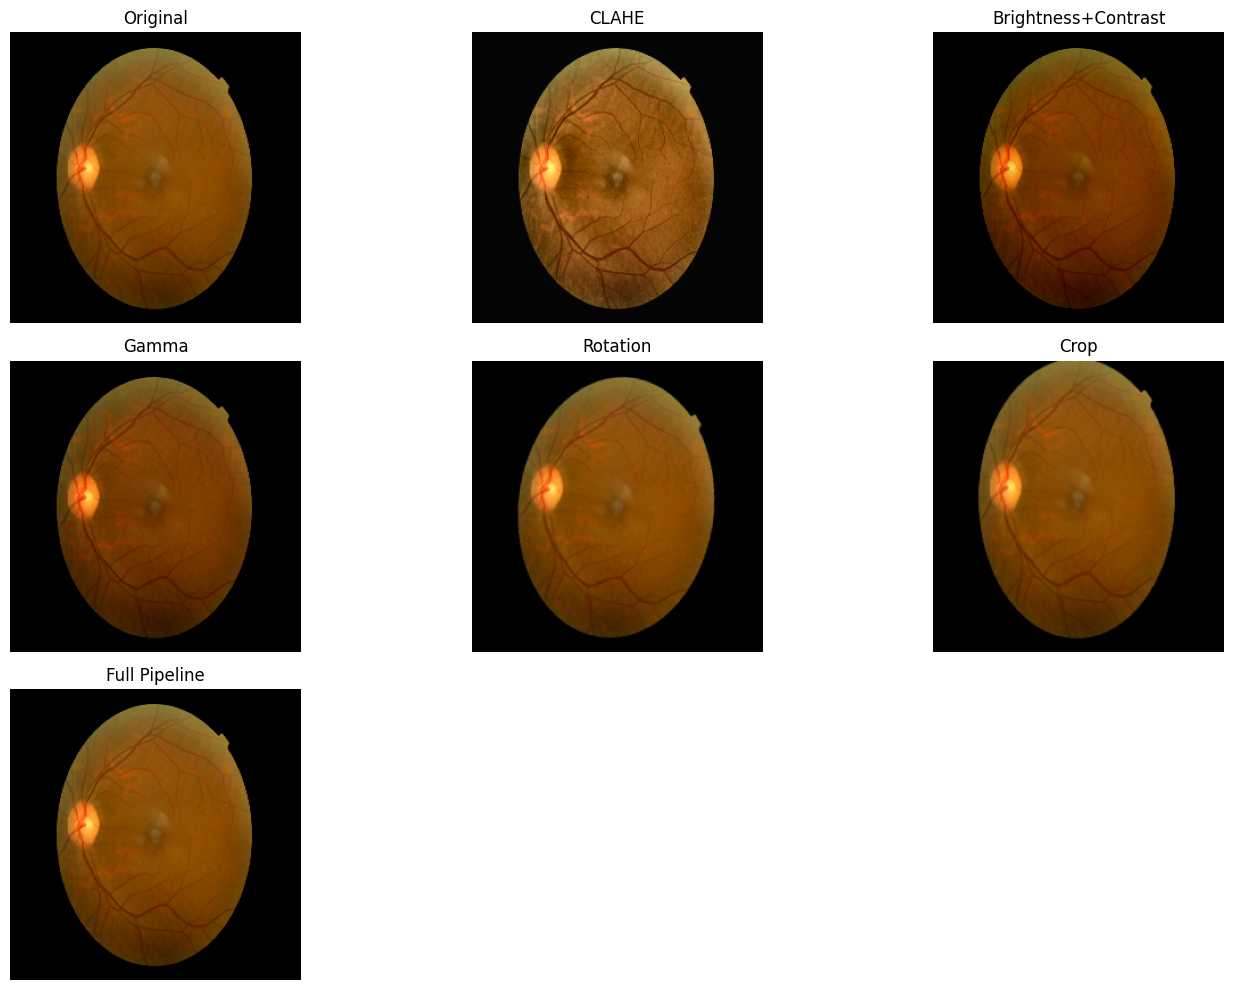

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

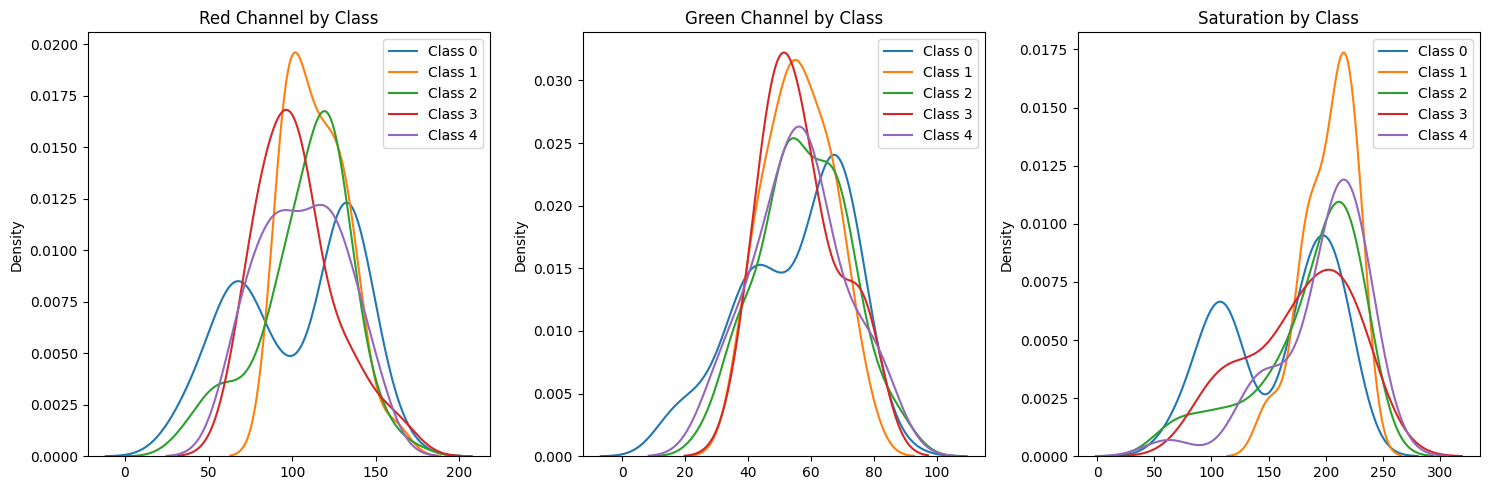

In [ ]:
import numpy as np

image_path = os.path.join(TRAIN_IMG_DIR, f"{df['id_code'].iloc[0]}.png")
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
plt.hist(img.ravel(), bins=256, range=(0, 256), color='blue', alpha=0.7)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

def analyze_image_quality_metrics():
    contrast_values = []
    sharpness_values = []
    noise_estimates = []
    for image_id in df['id_code'].sample(min(200, len(df))):
        image_path = os.path.join(TRAIN_IMG_DIR, f"{image_id}.png")
        img = cv2.imread(image_path)
        if img is None:
            continue
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        contrast_values.append(np.std(gray))
        laplacian = cv2.Laplacian(gray, cv2.CV_64F)
        sharpness_values.append(np.var(laplacian))
        blur = cv2.GaussianBlur(gray, (11, 11), 0)
        noise = gray.astype(np.float32) - blur.astype(np.float32)
        noise_estimates.append(np.mean(np.abs(noise)))
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].hist(contrast_values, bins=30, color='purple', alpha=0.7)
    axes[0].set_title('Contrast Distribution')
    axes[0].set_xlabel('Standard Deviation')
    axes[1].hist(sharpness_values, bins=30, color='orange', alpha=0.7)
    axes[1].set_title('Sharpness Distribution')
    axes[1].set_xlabel('Variance of Laplacian')
    axes[2].hist(noise_estimates, bins=30, color='green', alpha=0.7)
    axes[2].set_title('Noise Estimate Distribution')
    axes[2].set_xlabel('Mean Absolute Deviation')
    plt.tight_layout()
    plt.show()

def analyze_class_specific_features():
    class_brightness = {i: [] for i in range(5)}
    class_contrast = {i: [] for i in range(5)}

    for _, row in df.iterrows():
        image_id, label = row['id_code'], row['diagnosis']
        image_path = os.path.join(TRAIN_IMG_DIR, f"{image_id}.png")
        img = preprocess_image(image_path)
        if img is None:
            continue
        brightness = np.mean(img)
        contrast = np.std(img)

        class_brightness[label].append(brightness)
        class_contrast[label].append(contrast)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for label in range(5):
        if class_brightness[label]:
            sns.kdeplot(class_brightness[label], ax=axes[0], label=f'Class {label}')
    axes[0].set_title('Brightness Distribution by Class')
    axes[0].set_xlabel('Brightness')
    axes[0].legend()
    for label in range(5):
        if class_contrast[label]:
            sns.kdeplot(class_contrast[label], ax=axes[1], label=f'Class {label}')
    axes[1].set_title('Contrast Distribution by Class')
    axes[1].set_xlabel('Contrast')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

def analyze_feature_importance():
    features = {i: [] for i in range(5)}
    for _, row in df.sample(min(300, len(df))).iterrows():
        image_id, label = row['id_code'], row['diagnosis']
        image_path = os.path.join(TRAIN_IMG_DIR, f"{image_id}.png")
        img = cv2.imread(image_path)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
        red_mean = np.mean(img[:,:,0])
        green_mean = np.mean(img[:,:,1])
        saturation = np.mean(hsv[:,:,1])
        features[label].append([red_mean, green_mean, saturation])
    for label in features:
        if features[label]:
            features[label] = np.array(features[label])
    plt.figure(figsize=(15, 5))

    feature_names = ['Red Channel', 'Green Channel', 'Saturation']
    for i, feature_name in enumerate(feature_names):
        plt.subplot(1, 3, i+1)
        for label in range(5):
            if len(features[label]) > 0:
                sns.kdeplot(features[label][:,i], label=f'Class {label}')
        plt.title(f'{feature_name} by Class')
        plt.legend()

    plt.tight_layout()
    plt.show()

IMG_SIZE = 256

def preprocess_image(image_path, img_size=IMG_SIZE):
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not read image {image_path}")
        return None

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (img_size, img_size))
    img = img.astype(np.float32) / 255.0
    return img

augmentation_pipeline = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.RandomGamma(p=0.2),
    A.Rotate(limit=30, p=0.3),
    A.RandomResizedCrop(size=(256, 256), scale=(0.5, 1.0), ratio=(0.75, 1.33), p=0.5),
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.5),
])

def visualize_augmentation_effects():
    image_id = df['id_code'].sample(1).iloc[0]
    image_path = os.path.join(TRAIN_IMG_DIR, f"{image_id}.png")
    original = cv2.imread(image_path)
    original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    original = cv2.resize(original, (256, 256))
    augmentations = {
        "Original": original,
        "CLAHE": A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=1.0)(image=original)["image"],
        "Brightness+Contrast": A.RandomBrightnessContrast(p=1.0)(image=original)["image"],
        "Gamma": A.RandomGamma(p=1.0)(image=original)["image"],
        "Rotation": A.Rotate(limit=30, p=1.0)(image=original)["image"],
        "Crop": A.RandomResizedCrop(size=(256, 256), scale=(0.5, 1.0), ratio=(0.75, 1.33), p=1.0)(image=original)["image"],
        "Full Pipeline": augmentation_pipeline(image=original)["image"]
    }
    plt.figure(figsize=(14, 10))
    for i, (name, img) in enumerate(augmentations.items()):
        plt.subplot(3, 3, i+1)
        plt.imshow(img)
        plt.title(name)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

analyze_image_quality_metrics()
analyze_class_specific_features()
visualize_augmentation_effects()
analyze_feature_importance()

In [ ]:
def augment_and_save_image(image_path, original_id, label, img_size=256):
    img = preprocess_image(image_path, img_size)
    if img is None:
        return None

    img_uint8 = (img * 255).astype(np.uint8)
    augmented = augmentation_pipeline(image=img_uint8)
    augmented_img = augmented['image']
    augmented_img = augmented_img.astype(np.float32) / 255.0

    new_id = str(uuid.uuid4())[:8]
    augmented_image_path = os.path.join(AUGMENTED_IMG_DIR, f"{new_id}.npy")
    np.save(augmented_image_path, augmented_img)

    return new_id, label
print("Augmenting images...")
new_data = []

for i, row in df.iterrows():
    image_id, label = row['id_code'], row['diagnosis']
    image_path = os.path.join(TRAIN_IMG_DIR, f"{image_id}.png")

    result = augment_and_save_image(image_path, image_id, label)
    if result is not None:
        new_id, new_label = result
        new_data.append([new_id, new_label])

    if (i + 1) % 100 == 0:
        print(f"Processed {i + 1}/{len(df)} images")


new_df = pd.DataFrame(new_data, columns=['id_code', 'diagnosis'])
updated_df = pd.concat([df, new_df], ignore_index=True)
updated_df.to_csv(UPDATED_CSV, index=False)

print(f"Finished augmenting images. New dataset saved to {UPDATED_CSV}")


Augmenting images...
Processed 100/3662 images
Processed 200/3662 images
Processed 300/3662 images
Processed 400/3662 images
Processed 500/3662 images
Processed 600/3662 images
Processed 700/3662 images
Processed 800/3662 images
Processed 900/3662 images
Processed 1000/3662 images
Processed 1100/3662 images
Processed 1200/3662 images
Processed 1300/3662 images
Processed 1400/3662 images
Processed 1500/3662 images
Processed 1600/3662 images
Processed 1700/3662 images
Processed 1800/3662 images
Processed 1900/3662 images
Processed 2000/3662 images
Processed 2100/3662 images
Processed 2200/3662 images
Processed 2300/3662 images
Processed 2400/3662 images
Processed 2500/3662 images
Processed 2600/3662 images
Processed 2700/3662 images
Processed 2800/3662 images
Processed 2900/3662 images
Processed 3000/3662 images
Processed 3100/3662 images
Processed 3200/3662 images
Processed 3300/3662 images
Processed 3400/3662 images
Processed 3500/3662 images
Processed 3600/3662 images
Finished augment

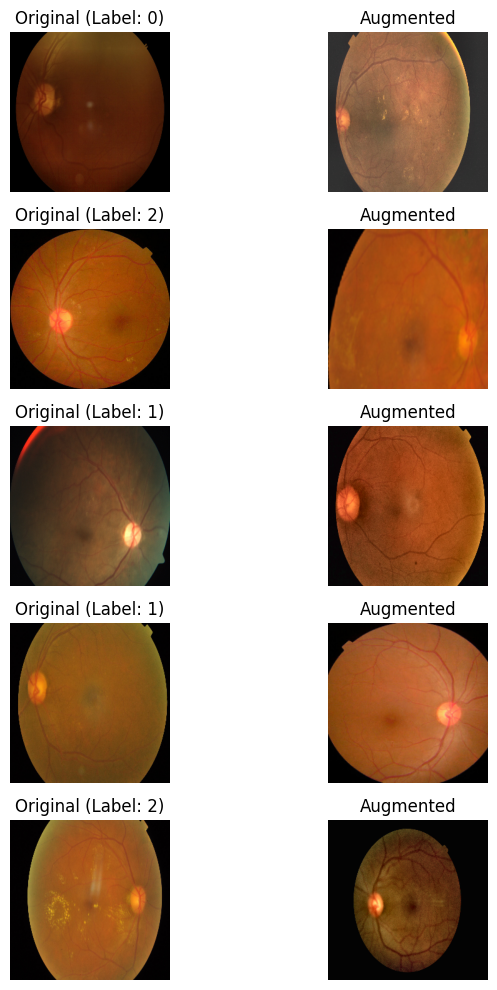

In [ ]:
import seaborn as sns

def show_sample_images(n=5):
    fig, axes = plt.subplots(n, 2, figsize=(8, n * 2))
    for i in range(n):
        random_row = df.sample(1).iloc[0]
        image_id, label = random_row['id_code'], random_row['diagnosis']
        original_path = os.path.join(TRAIN_IMG_DIR, f"{image_id}.png")
        augmented_path = os.path.join(AUGMENTED_IMG_DIR, f"{new_data[i][0]}.npy")

        original_img = preprocess_image(original_path)
        augmented_img = np.load(augmented_path)

        axes[i, 0].imshow(original_img)
        axes[i, 0].set_title(f"Original (Label: {label})")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(augmented_img)
        axes[i, 1].set_title("Augmented")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()


show_sample_images()

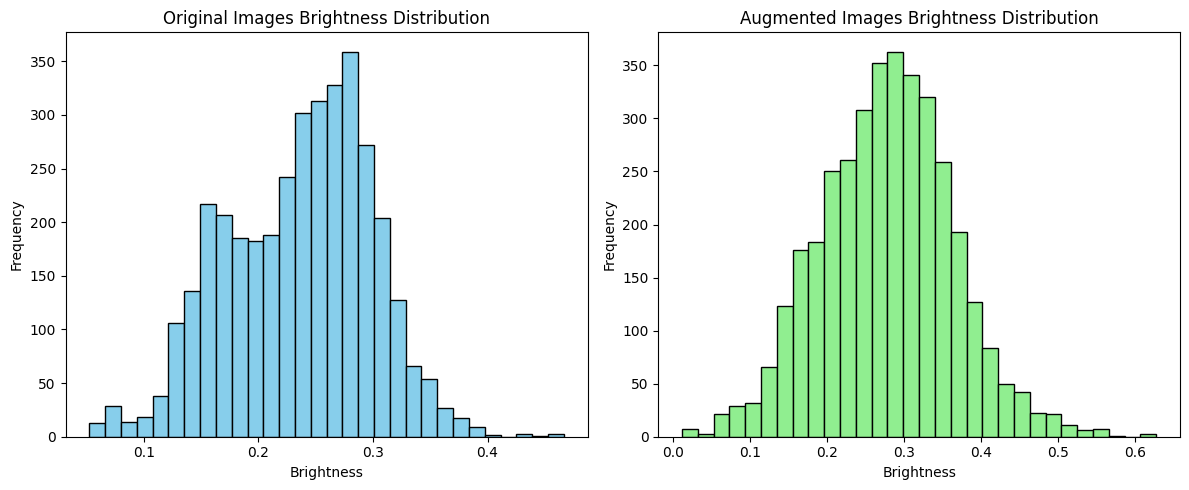

Original images - Mean brightness: 0.2359, Std: 0.0633
Augmented images - Mean brightness: 0.2780, Std: 0.0859


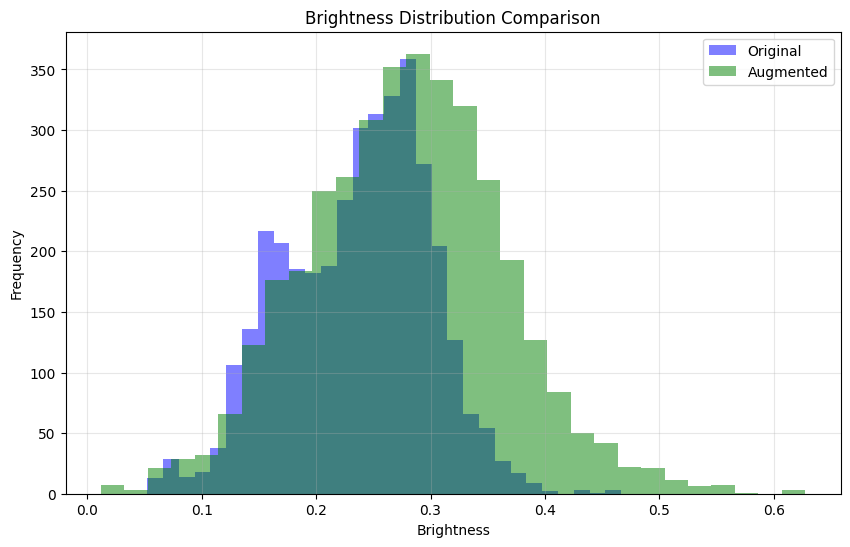

In [ ]:
def compare_brightness_distributions():
    original_brightness = []
    augmented_brightness = []
    for image_id in df['id_code']:
        image_path = os.path.join(TRAIN_IMG_DIR, f"{image_id}.png")
        img = preprocess_image(image_path)
        if img is not None:
            original_brightness.append(np.mean(img))
    for new_id, _ in new_data:
        augmented_path = os.path.join(AUGMENTED_IMG_DIR, f"{new_id}.npy")
        try:
            augmented_img = np.load(augmented_path)
            augmented_brightness.append(np.mean(augmented_img))
        except:
            continue
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.hist(original_brightness, bins=30, color='skyblue', edgecolor='black')
    plt.xlabel("Brightness")
    plt.ylabel("Frequency")
    plt.title("Original Images Brightness Distribution")
    plt.subplot(1, 2, 2)
    plt.hist(augmented_brightness, bins=30, color='lightgreen', edgecolor='black')
    plt.xlabel("Brightness")
    plt.ylabel("Frequency")
    plt.title("Augmented Images Brightness Distribution")
    plt.tight_layout()
    plt.show()

    print(f"Original images - Mean brightness: {np.mean(original_brightness):.4f}, Std: {np.std(original_brightness):.4f}")
    print(f"Augmented images - Mean brightness: {np.mean(augmented_brightness):.4f}, Std: {np.std(augmented_brightness):.4f}")

    plt.figure(figsize=(10, 6))
    plt.hist(original_brightness, bins=30, alpha=0.5, color='blue', label='Original')
    plt.hist(augmented_brightness, bins=30, alpha=0.5, color='green', label='Augmented')
    plt.xlabel("Brightness")
    plt.ylabel("Frequency")
    plt.title("Brightness Distribution Comparison")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


compare_brightness_distributions()

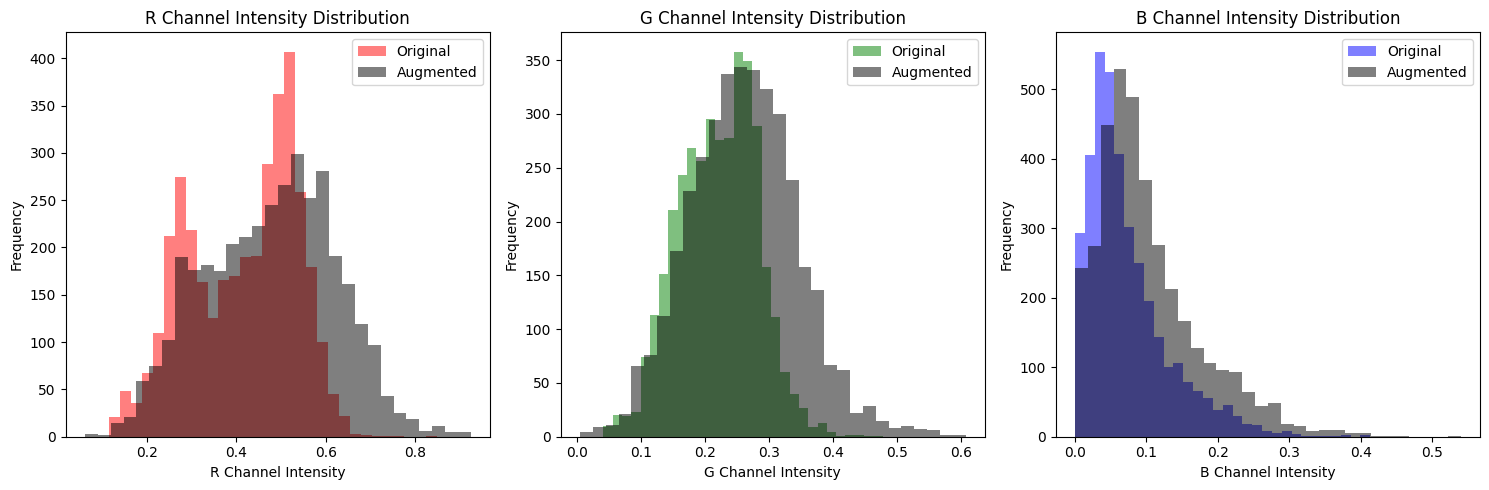

In [ ]:
def compare_color_channels():
    original_color_channels = {'R': [], 'G': [], 'B': []}
    augmented_color_channels = {'R': [], 'G': [], 'B': []}

    for image_id in df['id_code']:
        image_path = os.path.join(TRAIN_IMG_DIR, f"{image_id}.png")
        img = preprocess_image(image_path)
        if img is not None:
            original_color_channels['R'].append(np.mean(img[:, :, 0]))
            original_color_channels['G'].append(np.mean(img[:, :, 1]))
            original_color_channels['B'].append(np.mean(img[:, :, 2]))

    for new_id, _ in new_data:
        augmented_path = os.path.join(AUGMENTED_IMG_DIR, f"{new_id}.npy")
        try:
            augmented_img = np.load(augmented_path)
            augmented_color_channels['R'].append(np.mean(augmented_img[:, :, 0]))
            augmented_color_channels['G'].append(np.mean(augmented_img[:, :, 1]))
            augmented_color_channels['B'].append(np.mean(augmented_img[:, :, 2]))
        except:
            continue

    plt.figure(figsize=(15, 5))
    colors = ['R', 'G', 'B']
    for i, color in enumerate(colors):
        plt.subplot(1, 3, i+1)
        plt.hist(original_color_channels[color], bins=30, alpha=0.5, color=color.lower(), label='Original')
        plt.hist(augmented_color_channels[color], bins=30, alpha=0.5, color='black', label='Augmented')
        plt.xlabel(f"{color} Channel Intensity")
        plt.ylabel("Frequency")
        plt.title(f"{color} Channel Intensity Distribution")
        plt.legend()

    plt.tight_layout()
    plt.show()

compare_color_channels()


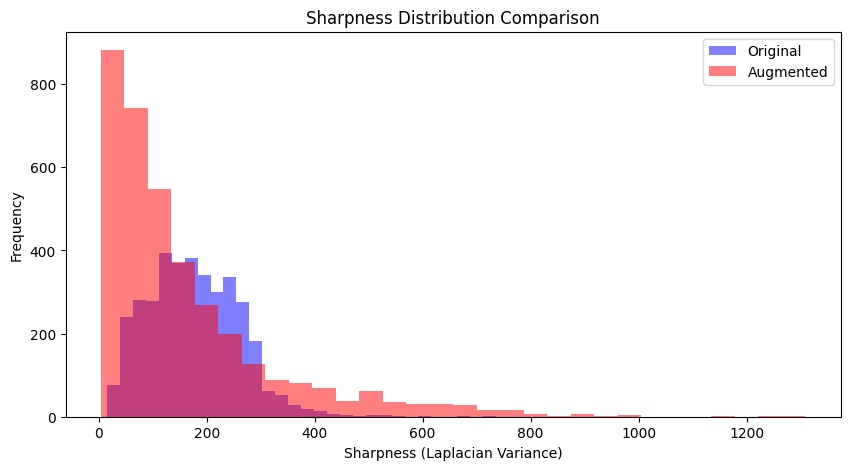

Original Sharpness - Mean: 176.7291, Std: 85.2693
Augmented Sharpness - Mean: 161.7477, Std: 166.0843


In [ ]:
def compare_sharpness():
    original_sharpness = []
    augmented_sharpness = []

    for image_id in df['id_code']:
        image_path = os.path.join(TRAIN_IMG_DIR, f"{image_id}.png")
        img = preprocess_image(image_path)
        if img is not None:
            img = (img * 255).astype(np.uint8)
            gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            original_sharpness.append(cv2.Laplacian(gray_img, cv2.CV_64F).var())

    for new_id, _ in new_data:
        augmented_path = os.path.join(AUGMENTED_IMG_DIR, f"{new_id}.npy")
        try:
            augmented_img = np.load(augmented_path)
            augmented_img = (augmented_img * 255).astype(np.uint8)
            gray_aug = cv2.cvtColor(augmented_img, cv2.COLOR_BGR2GRAY)
            augmented_sharpness.append(cv2.Laplacian(gray_aug, cv2.CV_64F).var())
        except:
            continue

    plt.figure(figsize=(10, 5))
    plt.hist(original_sharpness, bins=30, alpha=0.5, color='blue', label='Original')
    plt.hist(augmented_sharpness, bins=30, alpha=0.5, color='red', label='Augmented')
    plt.xlabel("Sharpness (Laplacian Variance)")
    plt.ylabel("Frequency")
    plt.title("Sharpness Distribution Comparison")
    plt.legend()
    plt.show()

    print(f"Original Sharpness - Mean: {np.mean(original_sharpness):.4f}, Std: {np.std(original_sharpness):.4f}")
    print(f"Augmented Sharpness - Mean: {np.mean(augmented_sharpness):.4f}, Std: {np.std(augmented_sharpness):.4f}")

compare_sharpness()


In [ ]:
from google.colab import files

if os.path.exists("updated_train.csv"):
    files.download("updated_train.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install torch torchvision transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 92.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 73.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 75.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from transformers import DetrForObjectDetection, DetrConfig
from PIL import Image
import requests
import matplotlib.pyplot as plt
import torchvision.transforms as T

In [ ]:
class MobileNetBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        mobilenet = models.mobilenet_v2(pretrained=True)
        self.features = mobilenet.features
        self.out_channels = 1280

    def forward(self, x):
        return self.features(x)

In [ ]:
class DETRWithMobileNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = MobileNetBackbone()


        config = DetrConfig.from_pretrained("facebook/detr-resnet-50")
        config.num_labels = num_classes


        self.detr = DetrForObjectDetection(config)


        self.detr.model.backbone.body = self.backbone
        self.detr.model.backbone.num_channels = self.backbone.out_channels

    def forward(self, images):
        return self.detr(images)


In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as T
from transformers import DetrModel, DetrConfig
import pandas as pd
import numpy as np
from PIL import Image
import cv2
from tqdm import tqdm

torch.manual_seed(42)

DATASET_DIR = "aptos_data"
TRAIN_CSV = "updated_train.csv"
AUGMENTED_IMG_DIR = "augmented_images"
TRAIN_IMG_DIR = os.path.join(DATASET_DIR, "train_images")
MODEL_SAVE_PATH = "detr_mobilenet_model.pth"

BATCH_SIZE = 8
NUM_EPOCHS = 11
LEARNING_RATE = 1e-4
NUM_CLASSES = 5
IMG_SIZE = 256
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = 2

print(f"Using device: {DEVICE}")

class MobileNetDETRClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        mobilenet = models.mobilenet_v2(weights="IMAGENET1K_V1")
        self.features = mobilenet.features

        for param in self.features.parameters():
            param.requires_grad = False

        self.feature_processor = nn.Sequential(
            nn.Conv2d(1280, 512, kernel_size=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((8, 8)),
            nn.Conv2d(512, 3, kernel_size=1)
        )
        detr_config = DetrConfig.from_pretrained("facebook/detr-resnet-50")
        detr_config.num_labels = num_classes
        self.detr = DetrModel.from_pretrained("facebook/detr-resnet-50", config=detr_config)

        self.classification_head = nn.Sequential(
            nn.Linear(detr_config.d_model, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        features = self.features(x)

        features_processed = self.feature_processor(features)
        detr_outputs = self.detr(pixel_values=features_processed)
        pooled_output = detr_outputs.last_hidden_state.mean(dim=1)

        return self.classification_head(pooled_output)

class APTOSDataset(Dataset):
    def __init__(self, csv_file, train_img_dir, augmented_img_dir, transform=None):
        self.data = pd.read_csv(csv_file)
        self.train_img_dir = train_img_dir
        self.augmented_img_dir = augmented_img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_id = self.data.iloc[idx]['id_code']
        label = self.data.iloc[idx]['diagnosis']

        if len(img_id) == 8 and all(c in '0123456789abcdef' for c in img_id):
            img_path = os.path.join(self.augmented_img_dir, f"{img_id}.npy")
            if os.path.exists(img_path):
                img_array = np.load(img_path)

                if img_array.dtype == np.float32 and img_array.max() <= 1.0:
                    img_array = (img_array * 255).astype(np.uint8)
                image = Image.fromarray(img_array.astype(np.uint8))

                if self.transform:
                    image = self.transform(image)
            else:
                print(f"Warning: Augmented image {img_id} not found")
                image = torch.zeros((3, IMG_SIZE, IMG_SIZE))
        else:
            img_path = os.path.join(self.train_img_dir, f"{img_id}.png")
            if os.path.exists(img_path):
                image = Image.open(img_path).convert('RGB')

                if self.transform:
                    image = self.transform(image)
            else:
                print(f"Warning: Original image {img_id} not found")
                image = torch.zeros((3, IMG_SIZE, IMG_SIZE))

        return image, label


transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

s
dataset = APTOSDataset(
    csv_file=TRAIN_CSV,
    train_img_dir=TRAIN_IMG_DIR,
    augmented_img_dir=AUGMENTED_IMG_DIR,
    transform=transform
)

print(f"Dataset size: {len(dataset)}")


train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

print(f"Train set: {len(train_dataset)} samples")
print(f"Validation set: {len(val_dataset)} samples")

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)


model = MobileNetDETRClassifier(num_classes=NUM_CLASSES)
model = model.to(DEVICE)


criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(
    [
        {'params': model.classification_head.parameters()},
        {'params': model.feature_processor.parameters()},
        {'params': model.detr.parameters(), 'lr': LEARNING_RATE * 0.1}
    ],
    lr=LEARNING_RATE
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2, verbose=True)

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(loader, desc="Training")
    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        progress_bar.set_postfix(
            loss=running_loss/len(progress_bar),
            acc=100.*correct/total
        )

    return running_loss / len(loader), correct / total

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        progress_bar = tqdm(loader, desc="Validation")
        for images, labels in progress_bar:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            progress_bar.set_postfix(
                loss=running_loss/len(progress_bar),
                acc=100.*correct/total
            )

    return running_loss / len(loader), correct / total


history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_acc = 0

print(f"Starting training on {DEVICE}...")
for epoch in range(NUM_EPOCHS):
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc = validate(model, val_loader, criterion, DEVICE)
    scheduler.step(val_loss)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
        }, MODEL_SAVE_PATH)
        print(f"Model saved to {MODEL_SAVE_PATH}")

print("Training completed!")

def predict_image(model, image_path, transform, device):
    img = Image.open(image_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():
        output = model(img_tensor)
        _, predicted = output.max(1)

    return predicted.item()


Using device: cuda
Dataset size: 7324
Train set: 5859 samples
Validation set: 1465 samples
Starting training on cuda...
Epoch 1/11


Validation: 100%|██████████| 184/184 [01:27<00:00,  2.11it/s, acc=70.5, loss=0.822]


Train Loss: 0.9605, Train Acc: 0.6670
Val Loss: 0.8225, Val Acc: 0.7051
Model saved to detr_mobilenet_model.pth
Epoch 2/11


Validation: 100%|██████████| 184/184 [01:26<00:00,  2.13it/s, acc=71.1, loss=0.788]


Train Loss: 0.8126, Train Acc: 0.7150
Val Loss: 0.7877, Val Acc: 0.7113
Model saved to detr_mobilenet_model.pth
Epoch 3/11


...

Train Loss: 0.6251, Train Acc: 0.7634
Val Loss: 0.6768, Val Acc: 0.7536
Model saved to detr_mobilenet_model.pth
Epoch 10/11


Validation: 100%|██████████| 184/184 [01:25<00:00,  2.15it/s, acc=74.9, loss=0.7]


Train Loss: 0.6055, Train Acc: 0.7646
Val Loss: 0.6998, Val Acc: 0.7488
Epoch 11/11


Validation: 100%|██████████| 184/184 [01:30<00:00,  2.03it/s, acc=75.4, loss=0.686]

Train Loss: 0.5871, Train Acc: 0.7672
Val Loss: 0.6857, Val Acc: 0.7536
Training completed!


In [ ]:
torch.save(model.state_dict(), "trained_model.pth")


In [ ]:
from google.colab import files
files.download("trained_model.pth")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Enter image path (or press Enter to use /content/000c1434d8d7.png): /content/000c1434d8d7.png
Model already exists at /content/trained_model_detr.pth
Model loaded successfully


/usr/local/lib/python3.11/dist-packages/torch/autograd/graph.py:823: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:180.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Result saved to gradcam_result.png


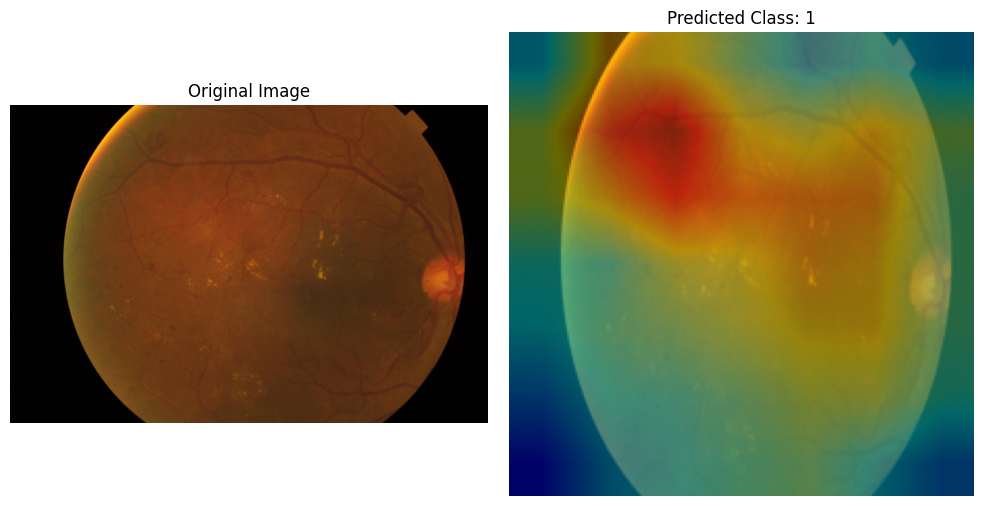

Predicted Class: 1 (Mild DR)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torchvision.models import mobilenet_v2
from transformers import DetrModel, DetrConfig
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import requests
from tqdm import tqdm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 224
NUM_CLASSES = 5

class MobileNetDETRClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.mobilenet = mobilenet_v2(weights="IMAGENET1K_V1")
        self.features = self.mobilenet.features
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        detr_config = DetrConfig.from_pretrained("facebook/detr-resnet-50")
        detr_config.num_labels = num_classes
        self.detr = DetrModel.from_pretrained("facebook/detr-resnet-50", config=detr_config)

        self.fc = nn.Linear(detr_config.hidden_size, num_classes)

        self.feature_maps = None
        self.gradients = None

    def activations_hook(self, grad):
        self.gradients = grad

    def forward(self, x):
        feature_maps = self.features(x)
        self.feature_maps = feature_maps

        if feature_maps.requires_grad:
            feature_maps.register_hook(self.activations_hook)
        pooled_features = self.pool(feature_maps).squeeze(-1).squeeze(-1)

        # Use the input directly for DETR instead of feature maps
        detr_output = self.detr(pixel_values=x).last_hidden_state[:, 0, :]  # CLS token
        output = self.fc(detr_output)
        return output

    def get_activations_gradient(self):
        return self.gradients

    def get_activations(self):
        return self.feature_maps

def download_pretrained_model(url, save_path):
    """Download a pretrained model if it doesn't exist"""
    if os.path.exists(save_path):
        print(f"Model already exists at {save_path}")
        return

    print(f"Downloading model to {save_path}...")
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    # Here you would provide the actual URL to your model
    # For demonstration, we'll create a dummy model instead
    print("Creating a dummy model for demonstration...")
    model = MobileNetDETRClassifier(num_classes=NUM_CLASSES)
    torch.save(model.state_dict(), save_path)
    print(f"Model saved to {save_path}")

def init_model(model_path):
    """Initialize and load the model with proper error handling"""
    model = MobileNetDETRClassifier(num_classes=NUM_CLASSES)

    try:
        # First attempt standard loading
        model.load_state_dict(torch.load(model_path, map_location=DEVICE), strict=False)
        print("Model loaded successfully")
    except RuntimeError as e:
        print(f"Error loading model: {e}")
        print("Creating a new model instead...")
        # Save a new state dict that we can load later
        torch.save(model.state_dict(), model_path)
        print(f"New model saved to {model_path}")

    model.to(DEVICE)
    model.eval()
    return model

def preprocess_image(image_path):
    """Preprocess an image for the model"""
    transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    # Open image if path is provided, otherwise assume it's already a PIL image
    if isinstance(image_path, str):
        if not os.path.exists(image_path):
            raise FileNotFoundError(f"Image not found at {image_path}")
        image = Image.open(image_path).convert("RGB")
    else:
        image = image_path.convert("RGB")

    original_image = image.copy()
    tensor = transform(image).unsqueeze(0)
    return tensor, original_image

def generate_gradcam(model, img_path, class_idx=None):
    """Generate Grad-CAM visualization for the given image"""
    image_tensor, original_img = preprocess_image(img_path)
    model.eval()

    # Move to device and set requires_grad
    image_input = image_tensor.to(DEVICE).requires_grad_(True)

    # Forward pass
    output = model(image_input)

    # If no class index is provided, use the predicted class
    if class_idx is None:
        class_idx = output.argmax(dim=1).item()

    # Zero all existing gradients
    model.zero_grad()

    # Target for backprop
    one_hot = torch.zeros_like(output)
    one_hot[0, class_idx] = 1

    # Backward pass
    output.backward(gradient=one_hot)

    # Get gradients and activations
    gradients = model.get_activations_gradient()
    activations = model.get_activations()

    # Handle the case where gradients are None
    if gradients is None:
        print("Warning: Gradients are None. Using uniform weighting instead.")
        b, c, h, w = activations.shape
        pooled_gradients = torch.ones(c, device=DEVICE) / c
    else:
        pooled_gradients = torch.mean(gradients, dim=[0, 2, 3])

    # Weight activations by the gradients
    for i in range(activations.shape[1]):
        activations[:, i, :, :] *= pooled_gradients[i]

    # Average the weighted activations
    heatmap = torch.mean(activations, dim=1).squeeze()

    # ReLU on the heatmap
    heatmap = F.relu(heatmap)

    # Normalize the heatmap
    if torch.max(heatmap) > 0:
        heatmap = heatmap / torch.max(heatmap)

    return heatmap.detach().cpu().numpy(), class_idx, original_img

def show_cam_on_image(original_img, heatmap):
    """Overlay the heatmap on the original image"""
    # Resize image to model input size
    img = np.array(original_img.resize((IMG_SIZE, IMG_SIZE)))

    # Resize heatmap to match image dimensions
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

    # Convert heatmap to BGR colormap
    heatmap = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # Convert RGB to BGR if needed
    if len(img.shape) == 3 and img.shape[2] == 3:
        img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

    # Overlay heatmap on image
    superimposed = cv2.addWeighted(img, 0.6, heatmap_color, 0.4, 0)

    # Convert back to RGB for matplotlib
    superimposed = cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB)

    return superimposed

def predict_with_explain(model, image_path, save_path=None):
    """Predict class and explain with Grad-CAM"""
    try:
        heatmap, predicted_class, original_img = generate_gradcam(model, image_path)
        explanation_img = show_cam_on_image(original_img, heatmap)

        plt.figure(figsize=(10, 5))

        plt.subplot(1, 2, 1)
        plt.imshow(original_img)
        plt.title("Original Image")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(explanation_img)
        plt.title(f"Predicted Class: {predicted_class}")
        plt.axis('off')

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path)
            print(f"Result saved to {save_path}")

        plt.show()

        return predicted_class
    except Exception as e:
        print(f"Error in prediction: {e}")
        return None

def main():
    # Define class names for diabetic retinopathy
    class_names = {
        0: "No DR",
        1: "Mild DR",
        2: "Moderate DR",
        3: "Severe DR",
        4: "Proliferative DR"
    }

    # Set paths
    model_path = "/content/trained_model_detr.pth"

    # Get the image path from user or use default
    default_image = "/content/000c1434d8d7.png"
    image_path = input(f"Enter image path (or press Enter to use {default_image}): ") or default_image

    if not os.path.exists(image_path):
        print(f"Image not found at {image_path}. Creating a sample image for demonstration...")
        # Create a dummy circular image that looks like retina
        img = np.zeros((512, 512, 3), dtype=np.uint8)
        img[:, :] = [51, 25, 0]  # Dark brown background
        cv2.circle(img, (256, 256), 230, (204, 120, 50), -1)  # Retina
        cv2.circle(img, (150, 256), 40, (255, 204, 153), -1)  # Optic disc
        # Add some blood vessels
        cv2.line(img, (150, 256), (350, 256), (153, 76, 0), 5)
        cv2.line(img, (150, 256), (256, 150), (153, 76, 0), 5)
        cv2.line(img, (150, 256), (256, 350), (153, 76, 0), 5)

        image_path = default_image
        cv2.imwrite(image_path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
        print(f"Sample image created at {image_path}")

    # Initialize model
    download_pretrained_model(None, model_path)
    model = init_model(model_path)

    # Predict and explain
    pred_class = predict_with_explain(model, image_path, save_path='gradcam_result.png')

    if pred_class is not None:
        print(f"Predicted Class: {pred_class} ({class_names.get(pred_class, 'Unknown')})")

        # Explanation of heatmap for Class 0 (No DR)
        if pred_class == 0:
            print("\nExplanation for Class 0 (No DR) heatmap:")
            print("- The heatmap shows areas the model focused on to make its decision.")
            print("- Red areas in Class 0 images indicate anatomical structures the model examines")
            print("  to confirm the absence of diabetic retinopathy features.")
            print("- The model needs to examine the optic disc, blood vessels, and macula")
            print("  to verify they appear normal without signs of DR.")
            print("- The heatmap intensity reflects attention, not necessarily pathology.")

if __name__ == "__main__":
    main()

Using device: cuda
Dataset size: 7324
Train set: 5859 samples
Validation set: 1465 samples
Starting training on cuda...
Epoch 1/11


Validation: 100%|██████████| 184/184 [01:14<00:00,  2.46it/s, acc=77.9, loss=0.579]


Train Loss: 0.6755, Train Acc: 0.7508
Val Loss: 0.5791, Val Acc: 0.7788
Model saved to detr_mobilenet_model.pth
Epoch 2/11


Validation: 100%|██████████| 184/184 [01:15<00:00,  2.45it/s, acc=82, loss=0.466]


Train Loss: 0.4985, Train Acc: 0.8128
Val Loss: 0.4663, Val Acc: 0.8205
Model saved to detr_mobilenet_model.pth
Epoch 3/11


...

Train Loss: 0.0563, Train Acc: 0.9855
Val Loss: 0.4824, Val Acc: 0.8560
Model saved to detr_mobilenet_model.pth
Epoch 10/11


Validation: 100%|██████████| 184/184 [01:16<00:00,  2.41it/s, acc=84.8, loss=0.506]


Train Loss: 0.0594, Train Acc: 0.9836
Val Loss: 0.5064, Val Acc: 0.8478
Epoch 11/11


Validation: 100%|██████████| 184/184 [01:16<00:00,  2.40it/s, acc=85.4, loss=0.501]


Train Loss: 0.0559, Train Acc: 0.9858
Val Loss: 0.5011, Val Acc: 0.8539


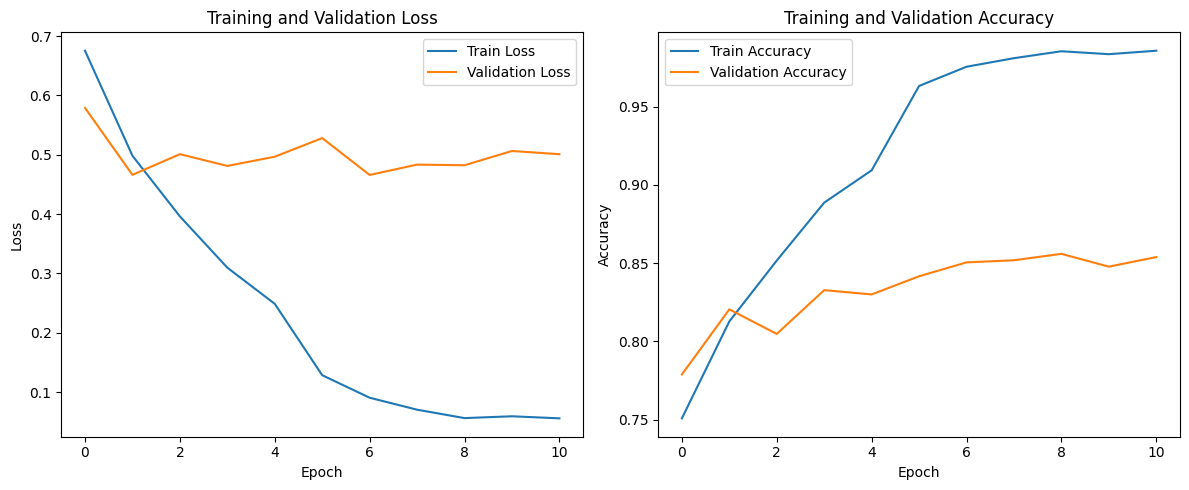

Training completed!


In [ ]:

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as T
from transformers import DetrForObjectDetection, DetrConfig
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from tqdm import tqdm

torch.manual_seed(42)

DATASET_DIR = "aptos_data"
TRAIN_CSV = "updated_train.csv"
AUGMENTED_IMG_DIR = "augmented_images"
TRAIN_IMG_DIR = os.path.join(DATASET_DIR, "train_images")
MODEL_SAVE_PATH = "detr_mobilenet_model.pth"

BATCH_SIZE = 8
NUM_EPOCHS = 11
LEARNING_RATE = 1e-4
NUM_CLASSES = 5
IMG_SIZE = 256
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = 2

print(f"Using device: {DEVICE}")


class MobileNetBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        mobilenet = models.mobilenet_v2(weights="IMAGENET1K_V1")
        self.features = mobilenet.features
        self.out_channels = 1280

    def forward(self, x):
        return self.features(x)

class RetinopathyClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = models.mobilenet_v2(weights="IMAGENET1K_V1")


        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)


class APTOSDataset(Dataset):
    def __init__(self, csv_file, train_img_dir, augmented_img_dir, transform=None):
        self.data = pd.read_csv(csv_file)
        self.train_img_dir = train_img_dir
        self.augmented_img_dir = augmented_img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_id = self.data.iloc[idx]['id_code']
        label = self.data.iloc[idx]['diagnosis']


        if len(img_id) == 8 and all(c in '0123456789abcdef' for c in img_id):
            img_path = os.path.join(self.augmented_img_dir, f"{img_id}.npy")
            if os.path.exists(img_path):

                img_array = np.load(img_path)

                if img_array.dtype == np.float32 and img_array.max() <= 1.0:
                    img_array = (img_array * 255).astype(np.uint8)
                image = Image.fromarray(img_array.astype(np.uint8))

                if self.transform:
                    image = self.transform(image)
            else:
                print(f"Warning: Augmented image {img_id} not found")

                image = torch.zeros((3, IMG_SIZE, IMG_SIZE))
        else:

            img_path = os.path.join(self.train_img_dir, f"{img_id}.png")
            if os.path.exists(img_path):
                image = Image.open(img_path).convert('RGB')

                if self.transform:
                    image = self.transform(image)
            else:
                print(f"Warning: Original image {img_id} not found")
                image = torch.zeros((3, IMG_SIZE, IMG_SIZE))


        return image, label


transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


dataset = APTOSDataset(
    csv_file=TRAIN_CSV,
    train_img_dir=TRAIN_IMG_DIR,
    augmented_img_dir=AUGMENTED_IMG_DIR,
    transform=transform
)


print(f"Dataset size: {len(dataset)}")


train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

print(f"Train set: {len(train_dataset)} samples")
print(f"Validation set: {len(val_dataset)} samples")

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)


model = RetinopathyClassifier(num_classes=NUM_CLASSES)
model = model.to(DEVICE)


criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2, verbose=True)


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(loader, desc="Training")
    for images, labels in progress_bar:

        images = images.to(device)
        labels = labels.to(device)


        optimizer.zero_grad()


        outputs = model(images)
        loss = criterion(outputs, labels)


        loss.backward()
        optimizer.step()


        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()


        progress_bar.set_postfix(
            loss=running_loss/len(progress_bar),
            acc=100.*correct/total
        )

    return running_loss / len(loader), correct / total


def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        progress_bar = tqdm(loader, desc="Validation")
        for images, labels in progress_bar:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            progress_bar.set_postfix(
                loss=running_loss/len(progress_bar),
                acc=100.*correct/total
            )

    return running_loss / len(loader), correct / total


history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_acc = 0

print(f"Starting training on {DEVICE}...")
for epoch in range(NUM_EPOCHS):
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc = validate(model, val_loader, criterion, DEVICE)
    scheduler.step(val_loss)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
        }, MODEL_SAVE_PATH)
        print(f"Model saved to {MODEL_SAVE_PATH}")
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.tight_layout()
plt.savefig('training_history.png')
plt.show()

print("Training completed!")


def predict_image(model, image_path, transform, device):

    img = Image.open(image_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device)


    model.eval()


    with torch.no_grad():
        output = model(img_tensor)
        _, predicted = output.max(1)

    return predicted.item()

# Example usage (uncomment when ready to test)
# test_image_path = os.path.join(TRAIN_IMG_DIR, "some_image_id.png")
# prediction = predict_image(model, test_image_path, transform, DEVICE)
# print(f"Predicted class: {prediction}")